In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [ ]:

from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d USERNAME/DATASET-NAME
!unzip DATASET-NAME.zip

Saving archive.zip to archive.zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
unzip:  cannot find or open DATASET-NAME.zip, DATASET-NAME.zip.zip or DATASET-NAME.zip.ZIP.


In [ ]:
# =====================================================
# INTERNSHIP TASK 1: DATA UNDERSTANDING
# Dataset: Titanic Dataset
# =====================================================
import pandas as pd
import numpy as np
import zipfile
import os
zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/titanic_data")

print("Dataset extracted successfully!\n")
csv_file = None

for root, dirs, files in os.walk("/content/titanic_data"):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)
            break

if csv_file is None:
    raise FileNotFoundError(" No CSV file found inside the ZIP file.")

print("CSV File Found:", csv_file)
df = pd.read_csv(csv_file)

print("\n" + "="*60)
print("FIRST 5 ROWS OF DATASET")
print("="*60)
print(df.head())
print("\n" + "="*60)
print("DATASET SIZE")
print("="*60)
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")
print("\n" + "="*60)
print("COLUMN NAMES")
print("="*60)
for col in df.columns:
    print(col)
print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)
print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
df.info()
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(df.describe())
print("\n" + "="*60)
print("CATEGORICAL DATA SUMMARY")
print("="*60)
print(df.describe(include='object'))
print("\n" + "="*60)
print("UNIQUE VALUES IN EACH COLUMN")
print("="*60)

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
print("\n" + "="*60)
print("DUPLICATE RECORDS")
print("="*60)
print("Duplicate Rows:", df.duplicated().sum())

print("\n" + "="*60)
print("FEATURE LIST")
print("="*60)

for column in df.columns:
    print(f"- {column}")
print("\n" + "="*60)
print("DATASET DESCRIPTION")
print("="*60)

print("""
The Titanic dataset contains information about passengers
who traveled on the RMS Titanic.

The dataset includes:
• Passenger demographics (Age, Sex)
• Passenger class information (Pclass)
• Ticket and fare details
• Family relationships aboard the ship
• Survival status

Target Variable:
• Survived
    0 = Did Not Survive
    1 = Survived

This dataset is commonly used for:
• Data Analysis
• Data Visualization
• Machine Learning
• Classification Problems
""")
if 'Survived' in df.columns:
    print("\n" + "="*60)
    print("SURVIVAL DISTRIBUTION")
    print("="*60)
    print(df['Survived'].value_counts())

if 'Sex' in df.columns:
    print("\n" + "="*60)
    print("GENDER DISTRIBUTION")
    print("="*60)
    print(df['Sex'].value_counts())

if 'Pclass' in df.columns:
    print("\n" + "="*60)
    print("PASSENGER CLASS DISTRIBUTION")
    print("="*60)
    print(df['Pclass'].value_counts())

print("\n Task 1 Completed Successfully!")
print("Dataset Loaded, Structure Understood, and Features Identified.")

Dataset extracted successfully!

CSV File Found: /content/titanic_data/Titanic-Dataset.csv

FIRST 5 ROWS OF DATASET
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN    

In [ ]:
# =====================================================
# TASK 2: DATA CLEANING & PREPROCESSING
# =====================================================

import pandas as pd
import zipfile
import os
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/titanic_data')
for root, dirs, files in os.walk('/content/titanic_data'):
    for file in files:
        if file.endswith('.csv'):
            csv_path = os.path.join(root, file)
df = pd.read_csv(csv_path)

print("Original Shape:", df.shape)
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())
if 'Age' in df.columns:
    df['Age'].fillna(df['Age'].median(), inplace=True)
if 'Embarked' in df.columns:
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
if 'Cabin' in df.columns:
    df['Cabin'].fillna('Unknown', inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

duplicates_before = df.duplicated().sum()
print("\nDuplicate Rows Before:", duplicates_before)

df.drop_duplicates(inplace=True)

duplicates_after = df.duplicated().sum()
print("Duplicate Rows After:", duplicates_after)

print("\nData Types:")
print(df.dtypes)

df.to_csv('Titanic_Cleaned.csv', index=False)

print("\nFinal Shape:", df.shape)
print("\nTask 2 Completed Successfully")

Original Shape: (891, 12)

Missing Values Before Cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Duplicate Rows Before: 0
Duplicate Rows After: 0

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Final Shape: (891, 12)

Task 2 Completed Successfully


/tmp/ipykernel_947/251948180.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_947/251948180.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

BASIC STATISTICS
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

Survival Distribution:
Survived
0    549
1    342
Name: count, 

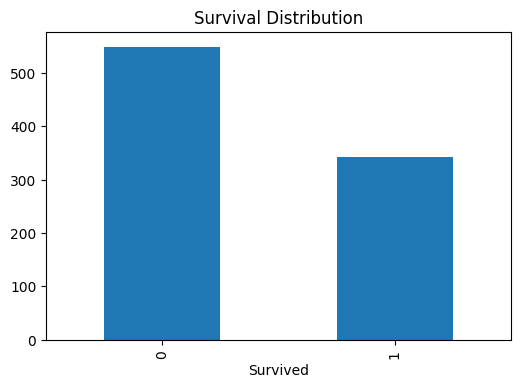

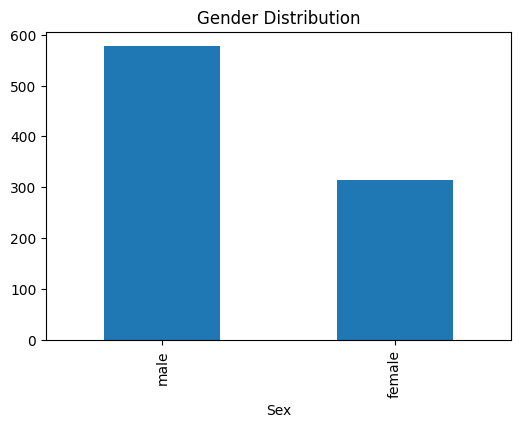

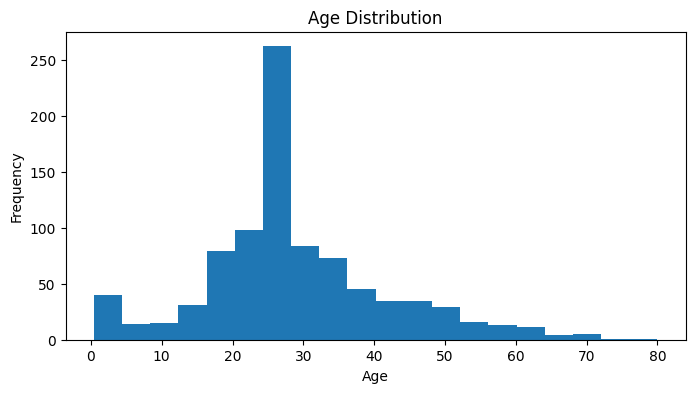

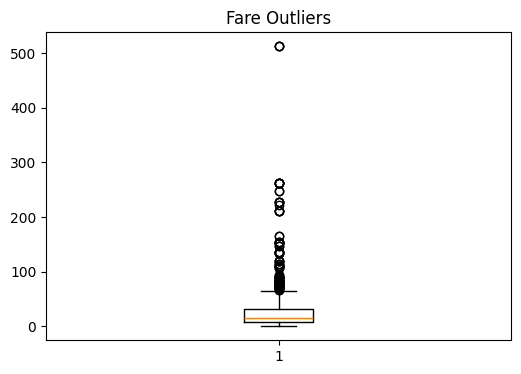


SUMMARY OF FINDINGS

1. Most passengers did not survive.
2. Male passengers were more than female passengers.
3. Passenger classes were not equally distributed.
4. Age and Fare showed noticeable variation.
5. Fare column contains several outliers.
6. The dataset reveals important survival patterns.


Task 3 Completed Successfully


In [ ]:
# =====================================================
# TASK 3: DATA ANALYSIS & PATTERN DISCOVERY
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('Titanic_Cleaned.csv')
print("="*60)
print("BASIC STATISTICS")
print("="*60)

print(df.describe())

print("\nSurvival Distribution:")
print(df['Survived'].value_counts())

print("\nGender Distribution:")
print(df['Sex'].value_counts())
print("\nPassenger Class Distribution:")
print(df['Pclass'].value_counts())

print("\nOUTLIER DETECTION")

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")
plt.figure(figsize=(6,4))
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Distribution")
plt.show()
plt.figure(figsize=(6,4))
df['Sex'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()
plt.figure(figsize=(8,4))
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
plt.figure(figsize=(6,4))
plt.boxplot(df['Fare'])
plt.title("Fare Outliers")
plt.show()

print("\nSUMMARY OF FINDINGS")
print("""
1. Most passengers did not survive.
2. Male passengers were more than female passengers.
3. Passenger classes were not equally distributed.
4. Age and Fare showed noticeable variation.
5. Fare column contains several outliers.
6. The dataset reveals important survival patterns.
""")

print("\nTask 3 Completed Successfully")

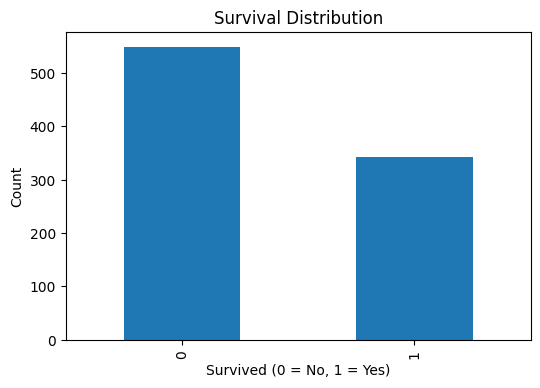

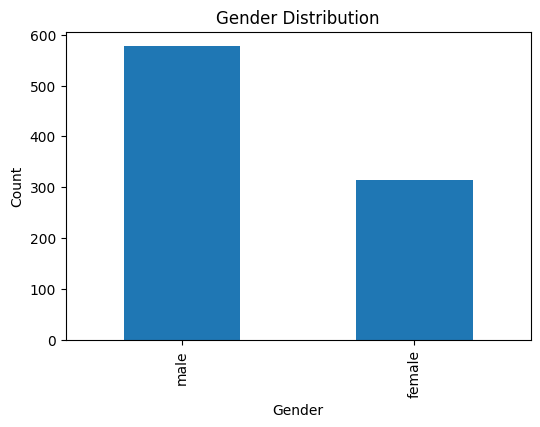

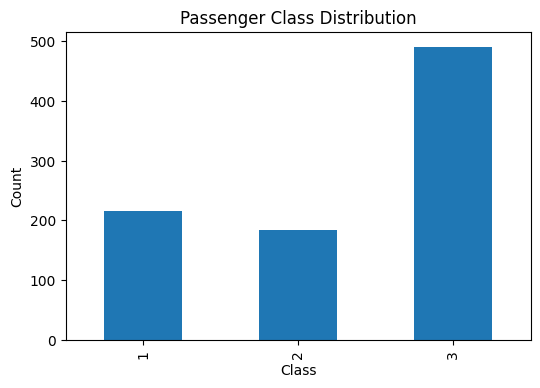

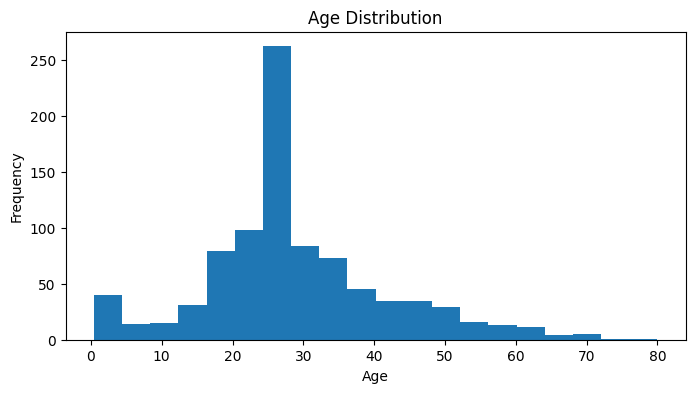

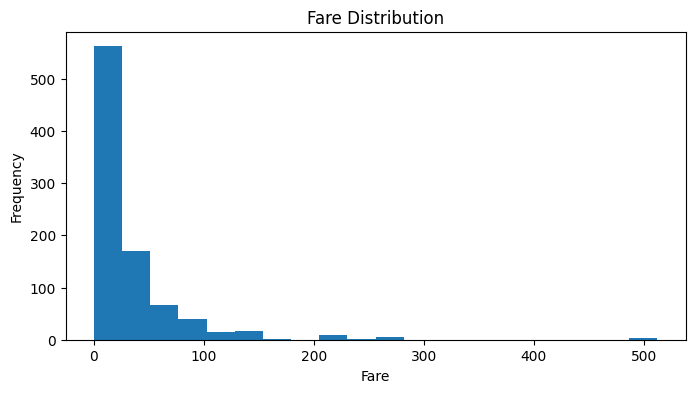

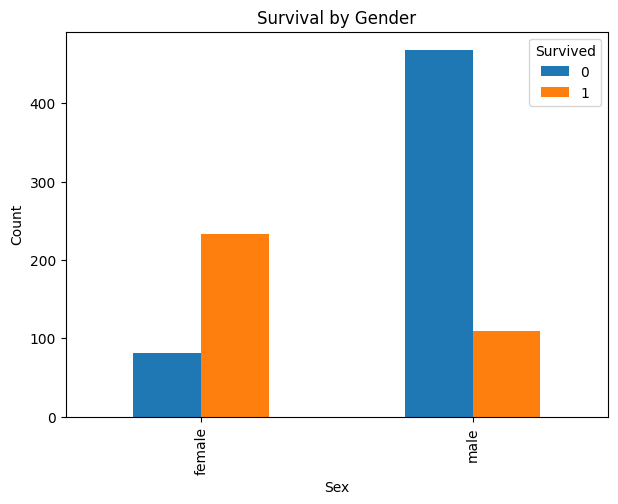

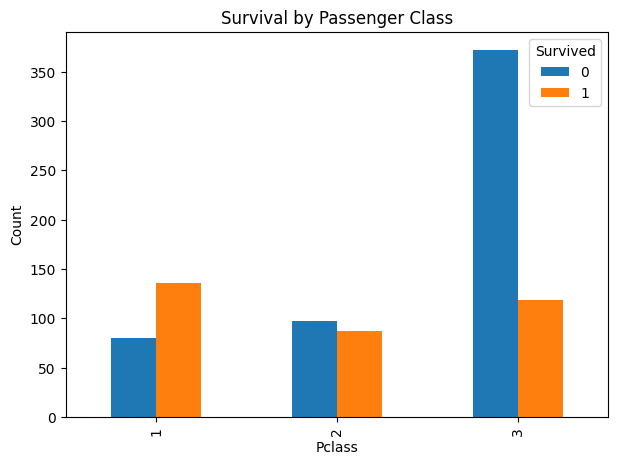


KEY INSIGHTS

1. More passengers died than survived.
2. Female passengers had a higher survival rate.
3. First-class passengers survived more often.
4. Most passengers were between 20 and 40 years old.
5. Ticket fares varied significantly.
6. Passenger class strongly influenced survival chances.



In [ ]:
# =====================================================
# TASK 4: DATA VISUALIZATION & STORYTELLING
# Titanic Dataset
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('Titanic_Cleaned.csv')
plt.figure(figsize=(6,4))
df['Survived'].value_counts().plot(kind='bar')
plt.title('Survival Distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()
plt.figure(figsize=(6,4))
df['Sex'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()
plt.figure(figsize=(6,4))
df['Pclass'].value_counts().sort_index().plot(kind='bar')
plt.title('Passenger Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()
plt.figure(figsize=(8,4))
plt.hist(df['Age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
plt.figure(figsize=(8,4))
plt.hist(df['Fare'], bins=20)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()
survival_gender = pd.crosstab(df['Sex'], df['Survived'])

survival_gender.plot(kind='bar', figsize=(7,5))
plt.title('Survival by Gender')
plt.ylabel('Count')
plt.show()
survival_class = pd.crosstab(df['Pclass'], df['Survived'])

survival_class.plot(kind='bar', figsize=(7,5))
plt.title('Survival by Passenger Class')
plt.ylabel('Count')
plt.show()
print("""
KEY INSIGHTS

1. More passengers died than survived.
2. Female passengers had a higher survival rate.
3. First-class passengers survived more often.
4. Most passengers were between 20 and 40 years old.
5. Ticket fares varied significantly.
6. Passenger class strongly influenced survival chances.
""")

In [ ]:
# =====================================================
# TASK 5: SIMPLE PREDICTIVE MODEL
# Titanic Survival Prediction
# =====================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
df = pd.read_csv('Titanic_Cleaned.csv')
features = ['Pclass', 'Sex', 'Age', 'Fare']

X = df[features]
y = df['Survived']

encoder = LabelEncoder()

X['Sex'] = encoder.fit_transform(X['Sex'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("""
MODEL INSIGHTS

1. Passenger class affects survival.
2. Gender strongly impacts survival probability.
3. Age contributes to prediction.
4. Fare also influences survival chances.
5. The model can predict whether a passenger survived.
""")

Model Accuracy: 74.86 %

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       105
           1       0.69      0.72      0.70        74

    accuracy                           0.75       179
   macro avg       0.74      0.74      0.74       179
weighted avg       0.75      0.75      0.75       179


Confusion Matrix
[[81 24]
 [21 53]]

MODEL INSIGHTS

1. Passenger class affects survival.
2. Gender strongly impacts survival probability.
3. Age contributes to prediction.
4. Fare also influences survival chances.
5. The model can predict whether a passenger survived.



/tmp/ipykernel_947/1692780145.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Sex'] = encoder.fit_transform(X['Sex'])
